# Netimpact

- *Input = demand*
- *Output = production*

#### Doel script: 
 1. Identificatie van piekmoment (zowel vraag als aanbod) ✅
 2. Doorsnede op piekmoment (zowel vraag als aanbod) ✅
 3. Visualisaties
    - Grafiek 1: Maximale piekvraag
        - Vraag ✅
        - Aanbod ✅
    - Grafiek 2: Maximale piekvraag uitgesplitst naar filters
        - Vraag ✅
        - Aanbod ✅

Een leeg scenario voor Zuid-Holland en het NBNL KM-scenario voor Zuid-Holland zijn als uitgangspunt genomen.

KM-scenario Zuid-Holland: https://pro.energytransitionmodel.com/scenarios/1365369



#### **User input**:
- Geef bij `3. File paths & mapping` aan welke curves je wil gebruiken.

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


### 2. Functions 

- Voor nu moeten de curves 'met de hand' worden gedownload uit de front-end, het idee is om dit later via pyETM te koppelen.
- Curves staan in de folder `scenario-tools/tests/netimpact/curves`


In [2]:
def read_mapping_file(mapping_filepath):
    """Read a mapping CSV file into a DataFrame."""
    return pd.read_csv(mapping_filepath)

def clean_column_names(df, suffix_type='input'):
    """
    Clean column names by removing '.input (MW)' or '.output (MW)'.
    suffix_type: 'input' or 'output'
    """
    pattern = rf'\.{suffix_type} \(MW\)'
    df.columns = df.columns.str.replace(pattern, '', regex=True)
    return df

def get_max_sum(df):
    """Return the row with the maximum total and the index of that row."""
    df['sum'] = df.iloc[:, 1:].sum(axis=1)
    idx_max = df['sum'].idxmax()
    return df.loc[[idx_max]], idx_max

def map_filters(df, mapping_df, suffix_type='input'):
    """
    Map column keys to their filters using the given mapping DataFrame.
    """
    pattern = r'\.input \(MW\)|\.output \(MW\)'
    mapping_df['key_clean'] = mapping_df['key'].str.replace(pattern, '', regex=True)
    df['filter'] = df.index.map(
        lambda key: mapping_df.loc[mapping_df['key_clean'] == key, 'filter'].values[0]
        if key in mapping_df['key_clean'].values else 'Unknown'
    )
    return df

def process_file(filepath, keys_to_keep, mapping_df, suffix_type='input'):
    """
    Read a CSV file and process it for max input/output and filters.
    suffix_type: 'input' or 'output'
    """
    df = pd.read_csv(filepath)
    df = df[[col for col in df.columns if col in keys_to_keep or col.lower() == 'time']].copy()
    df_clean = clean_column_names(df.filter(regex=rf"(?i)({suffix_type}|^time$)"), suffix_type)
    
    max_row_df, idx_max = get_max_sum(df_clean)
    df_transposed = max_row_df.set_index('Time').T.drop(index='sum')
    df_transposed = map_filters(df_transposed, mapping_df, suffix_type)
    return df_transposed, idx_max, max_row_df['Time'].values[0], max_row_df['sum'].values[0]


### 3. File paths & mapping

In [3]:
# Define mapping files
mapping_file_input = "mappings/mapping_input.csv"
mapping_file_output = "mappings/mapping_output.csv"

# Read both mappings
mapping_df_input = read_mapping_file(mapping_file_input)
mapping_df_output = read_mapping_file(mapping_file_output)

# Extract relevant keys
keys_to_keep_input = mapping_df_input['key'].tolist()
keys_to_keep_output = mapping_df_output['key'].tolist()

# Define merit order curve files
curve_filepaths = [
    'curves/ZH_empty_merit_order.csv',
    'curves/ZH_KM_merit_order.csv'
]


### 4. Process all files (data preparation)

##### Demand

In [4]:
processed_input_data = []
export_rows_input = []

for filepath in curve_filepaths:
    df_transposed, idx_max, time_of_max, max_value = process_file(
        filepath, keys_to_keep_input, mapping_df_input, suffix_type='input'
    )
    
    processed_input_data.append({
        'filepath': filepath,
        'df_transposed': df_transposed,
        'idx_max': idx_max,
        'time_of_max': time_of_max,
        'max_value': max_value
    })
    
    # Only sum numeric columns
    numeric_cols = df_transposed.select_dtypes(include=np.number).columns
    for key in df_transposed.index:
        export_rows_input.append({
            'file': filepath.split('/')[-1],
            'time_of_max': time_of_max,
            'key': key,
            'value': df_transposed.loc[key, numeric_cols].sum(),
            'filter': df_transposed.loc[key, 'filter']
        })
    
    print(f"{filepath.split('/')[-1]} - Max demand: {max_value:.1f} MW at {time_of_max}")



ZH_empty_merit_order.csv - Max demand: 4974.2 MW at 2030-12-07 09:00
ZH_KM_merit_order.csv - Max demand: 19813.7 MW at 2050-01-31 12:00


#### Production

In [5]:
processed_output_data = []
export_rows_output = []

for filepath in curve_filepaths:
    df_transposed, idx_max, time_of_max, max_value = process_file(
        filepath, keys_to_keep_output, mapping_df_output, suffix_type='output'
    )
    
    processed_output_data.append({
        'filepath': filepath,
        'df_transposed': df_transposed,
        'idx_max': idx_max,
        'time_of_max': time_of_max,
        'max_value': max_value
    })
    
    numeric_cols = df_transposed.select_dtypes(include=np.number).columns
    for key in df_transposed.index:
        export_rows_output.append({
            'file': filepath.split('/')[-1],
            'time_of_max': time_of_max,
            'key': key,
            'value': df_transposed.loc[key, numeric_cols].sum(),
            'filter': df_transposed.loc[key, 'filter']
        })
    
    print(f"{filepath.split('/')[-1]} - Max production: {max_value:.1f} MW at {time_of_max}")



ZH_empty_merit_order.csv - Max production: 4974.2 MW at 2030-12-07 09:00
ZH_KM_merit_order.csv - Max production: 19813.7 MW at 2050-01-31 12:00


### 5. Plot maximum peak per file

In [6]:
def plot_total_input_output(processed_input_data, processed_output_data, curve_filepaths):
    """Plot total input vs total output per scenario as grouped bars."""
    plt.figure(figsize=(10, 6))
    
    files = [f.split('/')[-1] for f in curve_filepaths]
    input_totals = [d['max_value'] for d in processed_input_data]
    output_totals = [d['max_value'] for d in processed_output_data]
    
    x = np.arange(len(files))
    width = 0.35
    
    plt.bar(x - width/2, input_totals, width, label='Input', color='tab:blue')
    plt.bar(x + width/2, output_totals, width, label='Output', color='tab:orange')
    
    plt.xticks(x, files, rotation=15)
    plt.ylabel('Power (MW)')
    plt.title('Maximale elektriciteitsvraag en -aanbod per scenario')
    plt.legend(['Vraag', 'Aanbod'])
    plt.tight_layout()
    plt.show()


In [7]:
def plot_total_input_output(processed_input_data, processed_output_data, curve_filepaths):
    """Plot total input vs total output per scenario as grouped bars, with values on top."""
    plt.figure(figsize=(10, 6))
    
    files = [f.split('/')[-1] for f in curve_filepaths]
    input_totals = [d['max_value'] for d in processed_input_data]
    output_totals = [d['max_value'] for d in processed_output_data]
    
    x = np.arange(len(files))
    width = 0.35
    
    bars_input = plt.bar(x - width/2, input_totals, width, label='Input', color='tab:blue')
    bars_output = plt.bar(x + width/2, output_totals, width, label='Output', color='tab:orange')
    
    # --- Voeg waarden boven elke staaf toe ---
    for bar in bars_input:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*max(input_totals+output_totals), 
                 f'{height:.0f}', ha='center', va='bottom', fontsize=9)
    
    for bar in bars_output:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*max(input_totals+output_totals), 
                 f'{height:.0f}', ha='center', va='bottom', fontsize=9)
    
    plt.xticks(x, files, rotation=15)
    plt.ylabel('MW')
    plt.title('Maximale elektriciteitsvraag en -aanbod per scenario')
    plt.legend(['Vraag', 'Aanbod'])
    plt.tight_layout()
    plt.show()



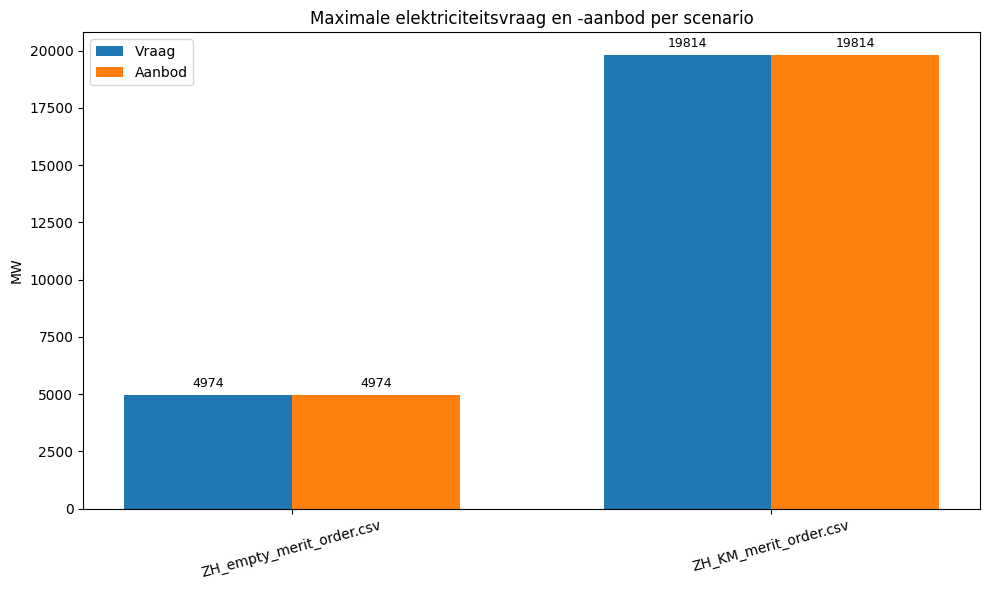

In [8]:
plot_total_input_output(processed_input_data, processed_output_data, curve_filepaths)

### 6. Plot maximum peak per category (*all* categories)

In [9]:
# --- Collect all filters from both input and output ---
all_filters = set()

for data in processed_input_data:
    all_filters.update(data['df_transposed']['filter'].unique())

for data in processed_output_data:
    all_filters.update(data['df_transposed']['filter'].unique())

# --- Create a shared color palette ---
colors = plt.cm.tab20.colors
filter_colors = {filt: colors[i % len(colors)] for i, filt in enumerate(sorted(all_filters))}


# --- Define a plotting helper function ---
def plot_stacked_bars(processed_data, curve_filepaths, title, filter_colors):
    """
    Create a stacked bar plot for processed input or output data
    using shared color mapping for consistent filter colors.
    """
    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(processed_data))
    
    # Plot stacked bars
    for i, data in enumerate(processed_data):
        df_grouped = (
            data['df_transposed']
            .drop(columns='filter')
            .groupby(data['df_transposed']['filter'])
            .sum()
        )
        bottom = 0
        for filter_name, row in df_grouped.iterrows():
            plt.bar(
                x_pos[i],
                row.iloc[0],
                bottom=bottom,
                color=filter_colors.get(filter_name, 'gray'),
                label=filter_name if i == 0 else ""
            )
            bottom += row.iloc[0]

    plt.xticks(x_pos, [f.split('/')[-1] for f in curve_filepaths])
    plt.ylabel('MW')
    plt.xlabel('File')
    plt.title(title)
    plt.legend(title='Filter', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_stacked_bars_minimal(processed_data, curve_filepaths, title, filter_colors):
    """
    Stacked bar plot.
    Only show filters with value > 0 anywhere in the dataset.
    """
    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(processed_data))
    
    # --- Bepaal welke filters daadwerkelijk een waarde > 0 hebben ---
    used_filters = set()
    for data in processed_data:
        df_grouped = (
            data['df_transposed']
            .drop(columns='filter')
            .groupby(data['df_transposed']['filter'])
            .sum()
        )
        for filter_name, row in df_grouped.iterrows():
            if row.sum() > 0:
                used_filters.add(filter_name)

    # --- Plot bars ---
    for i, data in enumerate(processed_data):
        df_grouped = (
            data['df_transposed']
            .drop(columns='filter')
            .groupby(data['df_transposed']['filter'])
            .sum()
        )
        bottom = 0
        for filter_name, row in df_grouped.iterrows():
            val = row.sum()
            if val == 0:
                continue
            plt.bar(
                x_pos[i],
                val,
                bottom=bottom,
                color=filter_colors.get(filter_name, 'gray')
            )
            bottom += val

    plt.xticks(x_pos, [f.split('/')[-1] for f in curve_filepaths])
    plt.ylabel('MW')
    plt.xlabel('File')
    plt.title(title)

    # --- Maak legenda handmatig met Patch (geen bars nodig) ---
    legend_patches = [mpatches.Patch(color=filter_colors[f], label=f) for f in sorted(used_filters)]
    plt.legend(handles=legend_patches, title='Filter', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

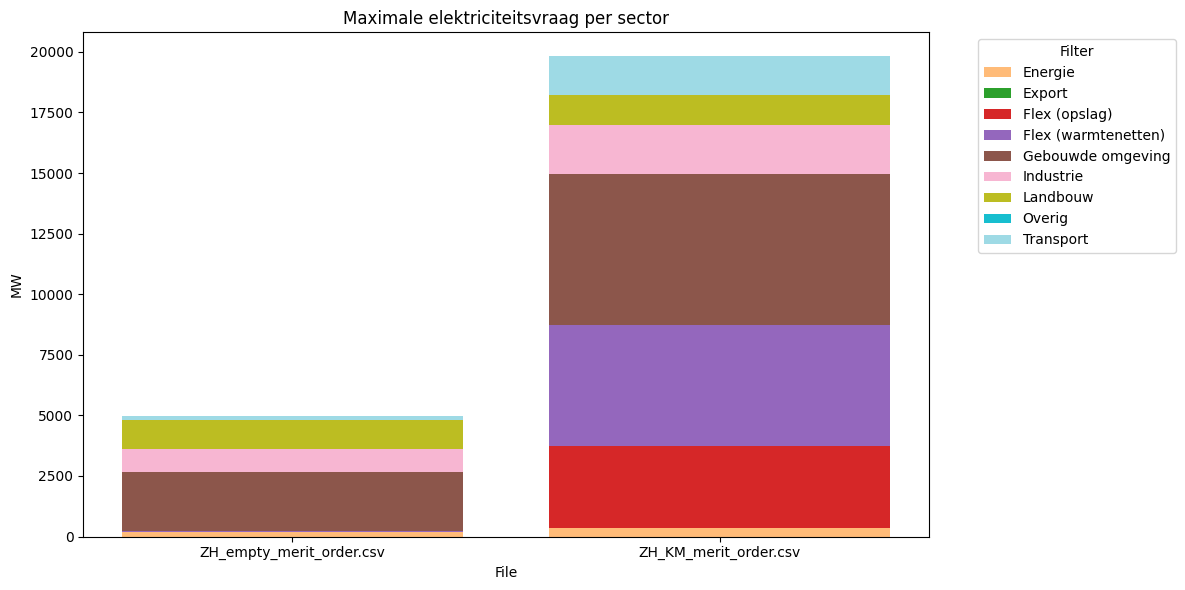

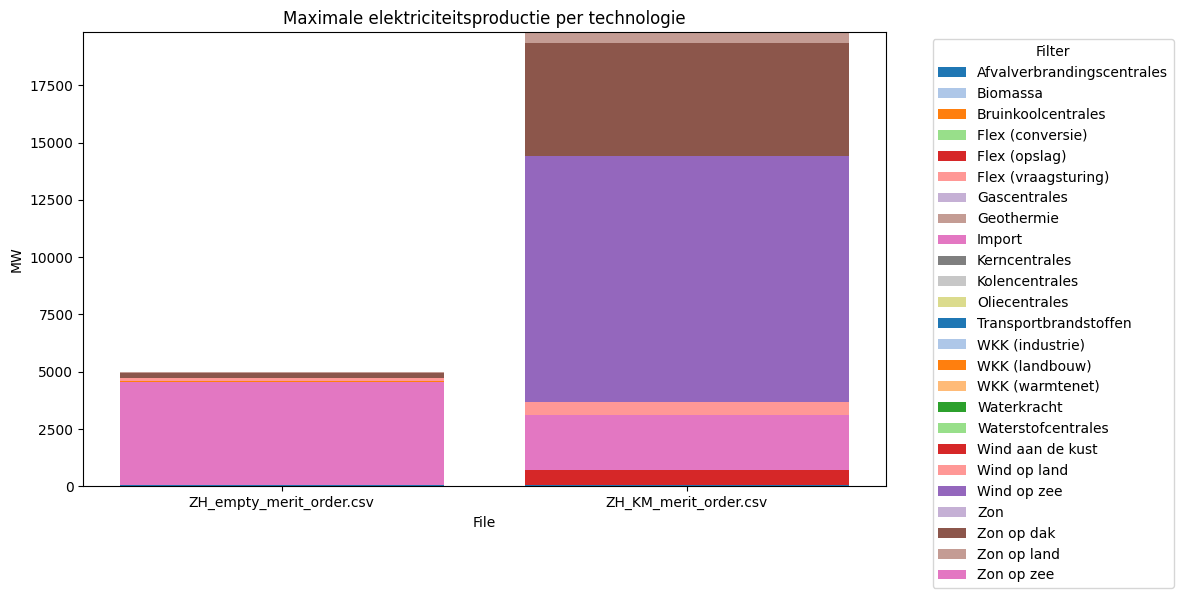

In [10]:
plot_stacked_bars(processed_input_data, curve_filepaths, title='Maximale elektriciteitsvraag per sector', filter_colors=filter_colors)
plot_stacked_bars(processed_output_data, curve_filepaths, title='Maximale elektriciteitsproductie per technologie', filter_colors=filter_colors)


*Run lines below to see less in the legend*

In [11]:
# plot_stacked_bars_minimal(processed_input_data, curve_filepaths, title='Maximale elektriciteitsvraag per sector', filter_colors=filter_colors)
# plot_stacked_bars_minimal(processed_output_data, curve_filepaths, title='Maximale elektriciteitsproductie per technologie', filter_colors=filter_colors)

### 7. Export processed data to csv-file

In [12]:
export_df_input = pd.DataFrame(export_rows_input)
export_df_input = export_df_input.sort_values(by=['file', 'filter', 'key']).reset_index(drop=True)
export_df_input.to_csv('output/max_input_summary.csv', index=False)
print("CSV export created: max_input_summary.csv")

export_df_output = pd.DataFrame(export_rows_output)
export_df_output = export_df_output.sort_values(by=['file', 'filter', 'key']).reset_index(drop=True)
export_df_output.to_csv('output/max_output_summary.csv', index=False)
print("CSV export created: max_output_summary.csv")

CSV export created: max_input_summary.csv
CSV export created: max_output_summary.csv
